In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
sns.set_style('darkgrid')
import os
import re
import pandas as pd

# IMport parent dir
import sys
sys.path.append('..')

from EBM.EBM_models import create_ebm

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_79691/273602268.py:37: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  pivot_df = df.pivot("Steps", "Model", "Time")


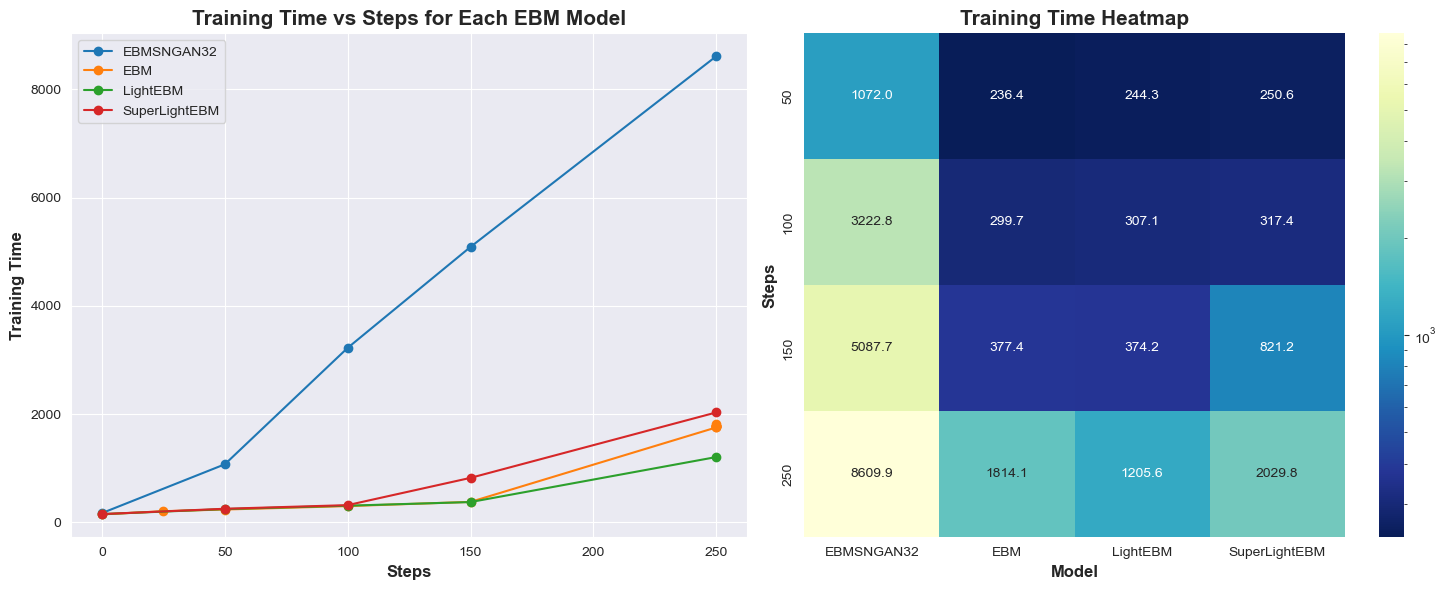

In [29]:
# Step 0: Import text from a .txt file
file_path = '/Users/sunaybhat/Desktop/purify_time.txt'  # Make sure to update this path to the location of your file
with open(file_path, 'r') as file:
    text = file.read()

# Step 1: Revised to parse the text for all four model types
data = []
for line in text.strip().split('\n'):
    if not line.startswith("Narcissus") and any(model in line for model in ['SuperLightEBM', 'LightEBM', 'EBM', 'EBMSNGAN32']):
        model_info = re.search(r"(EBMSNGAN32|EBM|SuperLightEBM|LightEBM|).*?_(\d+Steps)_T0.0001, Target Index 0: (\d+\.\d+)", line)
        if model_info:
            model_name = model_info.group(1)
            steps = int(model_info.group(2).replace("Steps", ""))
            train_time = float(model_info.group(3))
            data.append((model_name, steps, train_time))

# Step 2: Organize data into a dictionary
ebm_data = {}
for model_name, steps, train_time in data:
    if model_name not in ebm_data:
        ebm_data[model_name] = []
    ebm_data[model_name].append((steps, train_time))

# Convert data for heatmap plotting
heatmap_data = []
for model, values in ebm_data.items():
    for steps, time in values:
        if steps < 50: continue
        heatmap_data.append({"Model": model, "Steps": steps, "Time": time})

df = pd.DataFrame(heatmap_data)

# Drop duplicate model/steps take last
df = df.drop_duplicates(subset=["Model", "Steps"], keep="last")

# For the heatmap, we need to pivot the dataframe
pivot_df = df.pivot("Steps", "Model", "Time")
pivot_df = pivot_df[['EBMSNGAN32','EBM', 'LightEBM', 'SuperLightEBM']]

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Line plot for training time vs steps
for model, values in ebm_data.items():
    steps = [x[0] for x in values]
    times = [x[1] for x in values]
    axs[0].plot(steps, times, '-o',label=model)
axs[0].set_xlabel('Steps',fontsize=12,fontweight='bold')
axs[0].set_ylabel('Training Time',fontsize=12,fontweight='bold')
axs[0].legend()
axs[0].set_title('Training Time vs Steps for Each EBM Model',fontsize=15,fontweight='bold')

# Heatmap for training time values
sns.heatmap(pivot_df, annot=True, fmt=".1f", ax=axs[1], cmap="YlGnBu_r",norm=colors.LogNorm())
axs[1].set_title('Training Time Heatmap',fontsize=15,fontweight='bold')
axs[1].set_xlabel('Model',fontsize=12,fontweight='bold')
axs[1].set_ylabel('Steps',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()


### EBM Sizes in Terms of Num Parameters

In [57]:
nfs = [48,32,32,128]
for i,model_name in enumerate(['SuperLightEBM','LightEBM','EBM', 'EBMSNGAN32']):
    model = create_ebm(model_name,num_filters=nfs[i])
    print(f'Number of parameters in {model.__class__.__name__} (nf={nfs[i]}): {sum(p.numel() for p in model.parameters())}')

Number of parameters in SuperLightweightEBM (nf=48): 212065
Number of parameters in LightweightEBM (nf=32): 242881
Number of parameters in EBM (nf=32): 693569
Number of parameters in EBMSNGAN32 (nf=128): 1053824


In [8]:
import pickle

with open('/Users/sunaybhat/Desktop/benchmark_v2/bm_base100_ResNet34/9/poisons.pickle', "rb") as handle:
    buff = pickle.load(handle)

In [10]:
buff[0]

(<PIL.Image.Image image mode=RGB size=64x64>, 45)

## Compare EBMS

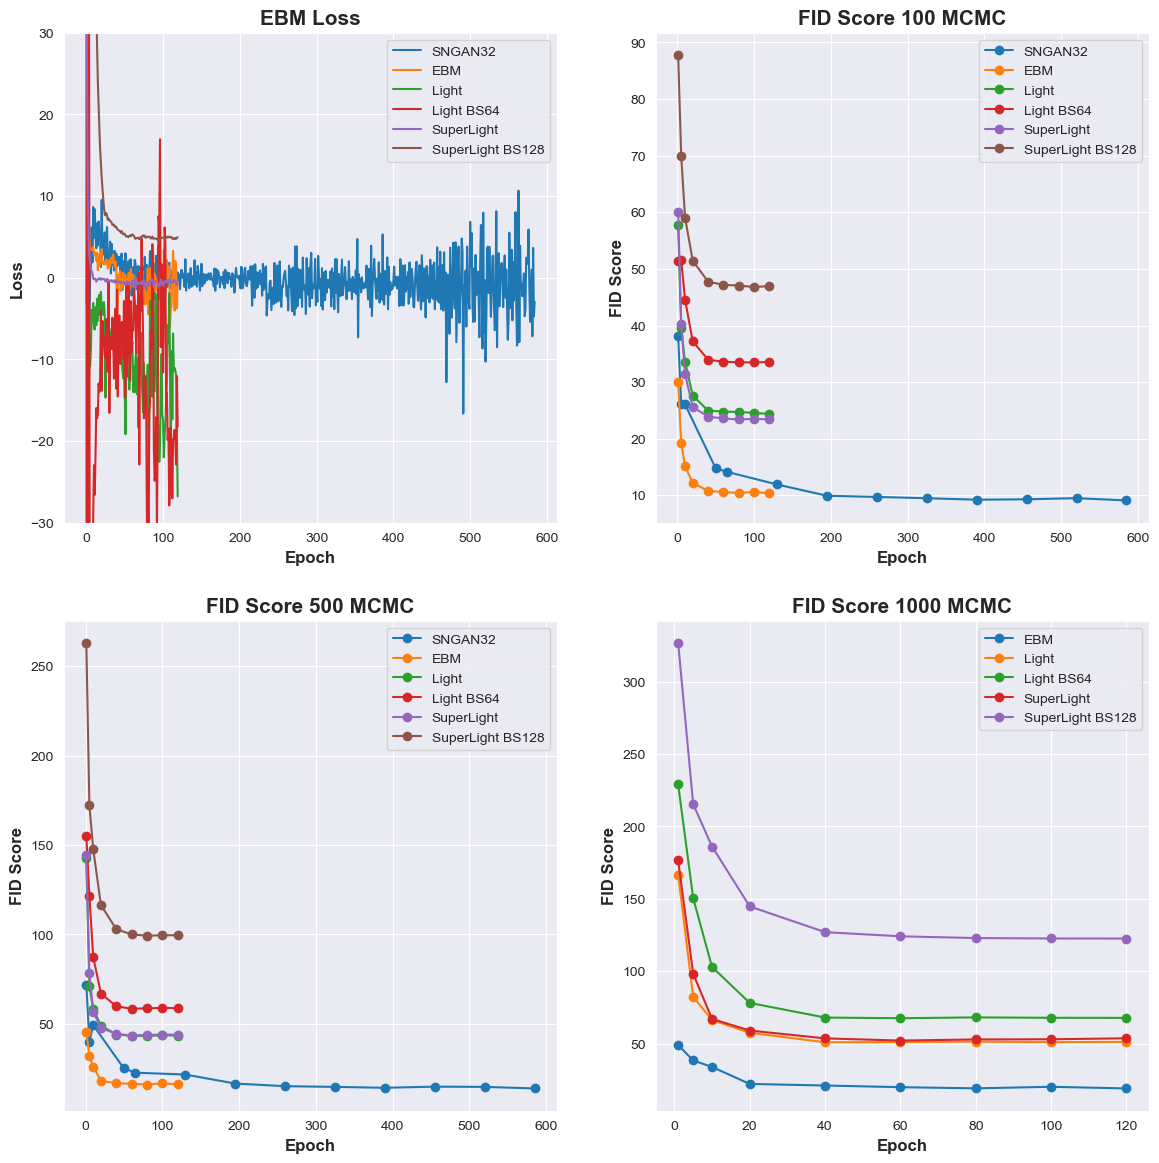

In [3]:
base_dir = '/Users/sunaybhat/Documents/GitHub/models'

dataset = 'cincic10_imagenet_subset'
EBMS = [['EBMSNGAN32','2023_12_22_07_47','SNGAN32'],
        ['EBM','2024_03_17_01_04','EBM'],
        ['LightEBM','2024_03_18_03_59','Light'],
        ['SuperLightEBM','2024_03_18_04_00','SuperLight'],
    ]

fig,axs = plt.subplots(2,2,figsize=(14,14))

for i,ebm in enumerate(EBMS):
    # Find all filepaths withs 'training_records' in the name
    records = [f for f in os.listdir(os.path.join(base_dir,ebm[0],dataset,ebm[1])) if 'training_record' in f]
    # Find the last epoch file
    last_epoch_file = max((file for file in records if 'epoch_' in file), key=lambda x: int(x.split('_')[-1].split('.')[0]))

    logs = torch.load(os.path.join(base_dir,ebm[0],dataset,ebm[1],last_epoch_file))

    axs[0,0].plot(logs['ebm_losses'],label=ebm[2])


    axs[0,1].plot(logs['fid_scores'][100].keys(),logs['fid_scores'][100].values(),'-o',label=ebm[2])


    axs[1,0].plot(logs['fid_scores'][500].keys(),logs['fid_scores'][500].values(),'-o',label=ebm[2])


    if 1000 in logs['fid_scores'].keys():
        axs[1,1].plot(logs['fid_scores'][1000].keys(),logs['fid_scores'][1000].values(),'-o',label=ebm[2])

axs[0,0].set_ylim(-30,30)
axs[0,0].set_title('EBM Loss',fontsize=15,fontweight='bold') 
axs[0,0].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[0,0].set_ylabel('Loss',fontsize=12,fontweight='bold')
axs[0,0].legend(fontsize=10)

axs[0,1].set_title('FID Score 100 MCMC',fontsize=15,fontweight='bold')
axs[0,1].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[0,1].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[0,1].legend(fontsize=10)

axs[1,0].set_title('FID Score 500 MCMC',fontsize=15,fontweight='bold')
axs[1,0].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[1,0].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[1,0].legend(fontsize=10)

axs[1,1].set_title('FID Score 1000 MCMC',fontsize=15,fontweight='bold')
axs[1,1].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[1,1].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[1,1].legend(fontsize=10)

In [52]:
logs['fid_scores'].keys()

dict_keys([100, 500])

In [16]:
last_epoch_file

'training_record_epoch_120.pt'